In [1]:
import numpy as np
import matplotlib.pyplot as plt
from geometry_class import Geometry
from parametrizations import Parameter
from visualization_fct import get_grid, eval_fct_on_grid
from dolfinx.fem import functionspace, Function
import pickle

In [35]:
filename = "./solutions/debug/Moure_4h_LastTestCase.pkl"
with open(filename, "rb") as f:
    data_Annika = pickle.load(f)

nx = data_Annika["geometry"]["nx"]
nz = data_Annika["geometry"]["nz"]
geom = Geometry()
geom.make_from_dict(data_Annika["geometry"])
domain = geom.make_domain(nx, nz)
[P0, P1, P2, P3] = geom.corner_points
V = functionspace(domain, ("CG", 1))
Q = functionspace(domain, ("DG", 0))
hw = Function(V)
phi = Function(Q)
T_i = Function(V)
T_w = Function(V)
p = Parameter(domain)

In [36]:
len(data_Annika["h_w"])

111

In [43]:
interval = data_Annika["saving_interval"]
t_obs = 109
hw.x.array[:] = data_Annika["h_w"][t_obs+1]
phi.x.array[:] = data_Annika["phi"][t_obs]
T_i.x.array[:] = data_Annika["T_i"][t_obs]
T_w.x.array[:] = data_Annika["T_w"][t_obs]
grid, x_plot, z_plot = get_grid(P0, P1, P2, P3, nx, nz)
pressure_head = eval_fct_on_grid(grid, hw, domain).reshape((nz, nx))
porosity = eval_fct_on_grid(grid, phi, domain).reshape((nz, nx))
Ti = eval_fct_on_grid(grid, T_i, domain).reshape((nz, nx))
Tw = eval_fct_on_grid(grid, T_w, domain).reshape((nz, nx))
h_c = pressure_head * (pressure_head < 0)
def Se(h_c, alpha, N):
    return (1 + (- alpha * h_c)**N)**((1 - N) / N)
theta_tot = p.theta_r.value + (0.9*porosity - p.theta_r.value)*Se(h_c, p.alpha.value, p.N.value)

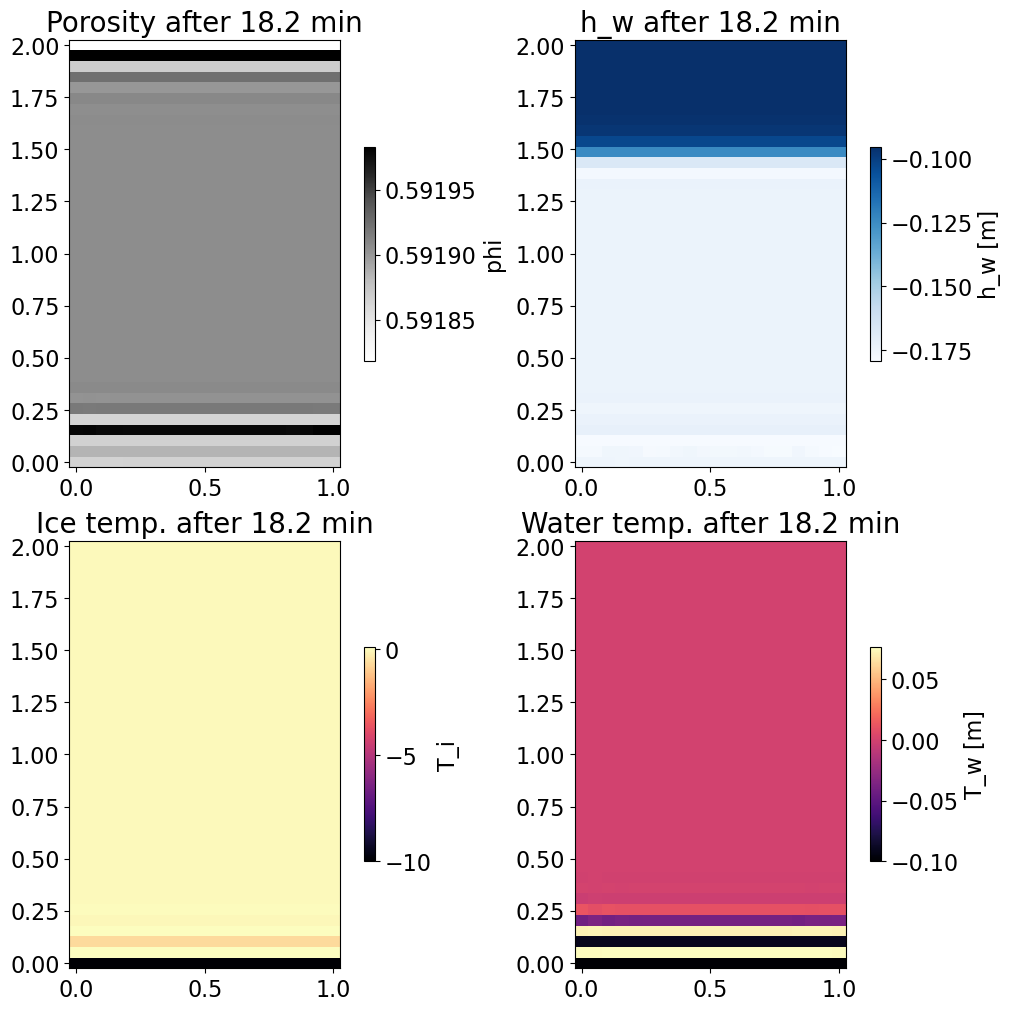

In [44]:
plt.rcParams.update({'font.size': 16})
fig, ax = plt.subplots(2,2, layout="constrained", figsize=(10,10))
pmsh1 = ax[0,0].pcolormesh(x_plot, z_plot, porosity, cmap="Greys")
ax[0,0].set_title(f"Porosity after {t_obs*interval/60:.1f} min", fontsize=20)
cbar1 = fig.colorbar(pmsh1, ax=ax[0,0], shrink=0.5)
cbar1.set_label("phi")

pmsh2 = ax[0,1].pcolormesh(x_plot, z_plot, pressure_head, cmap="Blues")
ax[0,1].set_title(f"h_w after {t_obs*interval/60:.1f} min", fontsize=20)
plt.xticks(fontsize=16)
cbar2 = fig.colorbar(pmsh2, ax=ax[0,1], shrink=0.5)
cbar2.set_label("h_w [m]")

pmsh3 = ax[1,0].pcolormesh(x_plot, z_plot, Ti, cmap="magma")
ax[1,0].set_title(f"Ice temp. after {t_obs*interval/60:.1f} min", fontsize=20)
cbar1 = fig.colorbar(pmsh3, ax=ax[1,0], shrink=0.5)
cbar1.set_label("T_i")

pmsh4 = ax[1,1].pcolormesh(x_plot, z_plot, Tw, cmap="magma")
ax[1,1].set_title(f"Water temp. after {t_obs*interval/60:.1f} min", fontsize=20)
plt.xticks(fontsize=16)
cbar2 = fig.colorbar(pmsh4, ax=ax[1,1], shrink=0.5)
cbar2.set_label("T_w [m]")

In [40]:
np.min(pressure_head)

np.float64(-0.20213234024311563)

In [34]:
p.min_hw.value

array(-0.17552469)